In [2]:
!pip install ydata-profiling

In [41]:
import pandas as pd
import numpy as np
#from ydata_profiling import ProfileReport

In [42]:
titanic = pd.read_csv('/content/Titanic-Dataset.csv')

titanic.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
643,644,1,3,"Foo, Mr. Choong",male,NaN,0,0,1601,56.4958,NaN,S
317,318,0,2,"Moraweck, Dr. Ernest",male,54.0,0,0,29011,14.0000,NaN,S
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NaN,S


In [43]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
''' # Generate the report
profile = ProfileReport(titanic, title='Dataset Profiling Report', explorative=True)

# Save the report as an HTML file to open in any browser
profile.to_file('output_report.html')'''

"# Generate the report\nprofile = ProfileReport(titanic, title='Dataset Profiling Report', explorative=True)\n\n# Save the report as an HTML file to open in any browser\nprofile.to_file('output_report.html')"

In [44]:
#Check duplicates
print(titanic.duplicated().sum())

0


In [45]:
#drop columns passengerid,name,ticket,cabin

titanic.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [46]:
#sum sibsp and Parch and make a new column family and remove both columns

titanic['Family'] = titanic['SibSp'] + titanic['Parch']
titanic.drop(['SibSp', 'Parch'], axis=1, inplace=True)

In [47]:
#Fill null values or remove

titanic.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
Fare,0
Embarked,2
Family,0


### #EDA Steps

In [48]:
from sklearn.impute import SimpleImputer

titanic_num = SimpleImputer(strategy='mean').fit_transform(titanic[['Age']])
titanic_cat = SimpleImputer(strategy='most_frequent').fit_transform(titanic[['Embarked']])

titanic_num = pd.DataFrame(titanic_num, columns=['Age'])
titanic_cat = pd.DataFrame(titanic_cat, columns=['Embarked'])

titanic = pd.concat([titanic.drop(['Age', 'Embarked'], axis=1), titanic_num, titanic_cat], axis=1)

In [49]:
titanic.describe()

,Survived,Pclass,Fare,Family,Age
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,32.204208,0.904602,29.699118
std,0.486592,0.836071,49.693429,1.613459,13.002015
min,0.000000,1.000000,0.000000,0.000000,0.420000
25%,0.000000,2.000000,7.910400,0.000000,22.000000
50%,0.000000,3.000000,14.454200,0.000000,29.699118
75%,1.000000,3.000000,31.000000,1.000000,35.000000
max,1.000000,3.000000,512.329200,10.000000,80.000000


In [50]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
titanic[['Age', 'Fare']] = scaler.fit_transform(titanic[['Age', 'Fare']])

In [51]:
#reduce Family size from int64 to int16

titanic['Family'] = titanic['Family'].astype('int16')

Data Preprocessing is Done.

In [52]:
#Label encoding target column survived
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
titanic['Survived'] = le.fit_transform(titanic['Survived'])

In [53]:
titanic.sample(5)

,Survived,Pclass,Sex,Fare,Family,Age,Embarked
696,0,3,male,0.015713,0,0.547625,S
311,1,1,female,0.512122,4,0.220910,C
674,0,2,male,0.000000,0,0.367921,S
494,0,3,male,0.015713,0,0.258608,S
151,1,1,female,0.129995,1,0.271174,S


In [76]:
#Split dataset in X feature and Y target
X = titanic.drop('Survived', axis=1)
Y = titanic['Survived']

In [77]:
#Split dataset
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test =  train_test_split(X, Y , test_size=0.2, random_state=100)

X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((712, 6), (179, 6), (712,), (179,))

In [78]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Create encoder
ohe = OneHotEncoder(drop='first', sparse_output=False)

# Fit on train and transform
X_train_new = ohe.fit_transform(X_train[['Sex', 'Embarked']])
X_test_new = ohe.transform(X_test[['Sex', 'Embarked']])

# Convert to DataFrame
X_train_new = pd.DataFrame(
    X_train_new,
    columns=ohe.get_feature_names_out(['Sex', 'Embarked']),
    index=X_train.index
)

X_test_new = pd.DataFrame(
    X_test_new,
    columns=ohe.get_feature_names_out(['Sex', 'Embarked']),
    index=X_test.index
)

# Drop old columns and concatenate
X_train = pd.concat(
    [X_train.drop(['Sex', 'Embarked'], axis=1), X_train_new],
    axis=1
)

X_test = pd.concat(
    [X_test.drop(['Sex', 'Embarked'], axis=1), X_test_new],
    axis=1
)

In [82]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((712, 7), (179, 7), (712,), (179,))

In [83]:
X_train

,Pclass,Fare,Family,Age,Sex_male,Embarked_Q,Embarked_S
408,3,0.015176,0,0.258608,1.0,0.0,1.0
480,3,0.091543,7,0.107816,1.0,0.0,1.0
510,3,0.015127,0,0.359135,1.0,1.0,0.0
609,1,0.299539,0,0.497361,0.0,0.0,1.0
547,2,0.027058,0,0.367921,1.0,0.0,0.0
...,...,...,...,...,...,...,...
855,3,0.018250,1,0.220910,0.0,0.0,1.0
871,1,0.102579,2,0.585323,0.0,0.0,1.0
835,1,0.162314,2,0.484795,0.0,0.0,0.0
792,3,0.135753,10,0.367921,0.0,0.0,1.0


In [84]:
X_test

,Pclass,Fare,Family,Age,Sex_male,Embarked_Q,Embarked_S
205,3,0.020421,1,0.019854,0.0,0.0,1.0
44,3,0.015379,0,0.233476,0.0,1.0,0.0
821,3,0.016908,0,0.334004,1.0,0.0,1.0
458,2,0.020495,0,0.623021,0.0,0.0,1.0
795,2,0.025374,0,0.484795,1.0,0.0,1.0
...,...,...,...,...,...,...,...
247,2,0.028302,2,0.296306,0.0,0.0,1.0
259,2,0.050749,1,0.623021,0.0,0.0,1.0
353,3,0.034743,1,0.308872,1.0,0.0,1.0
783,3,0.045771,3,0.367921,1.0,0.0,1.0


Now we implement graph

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

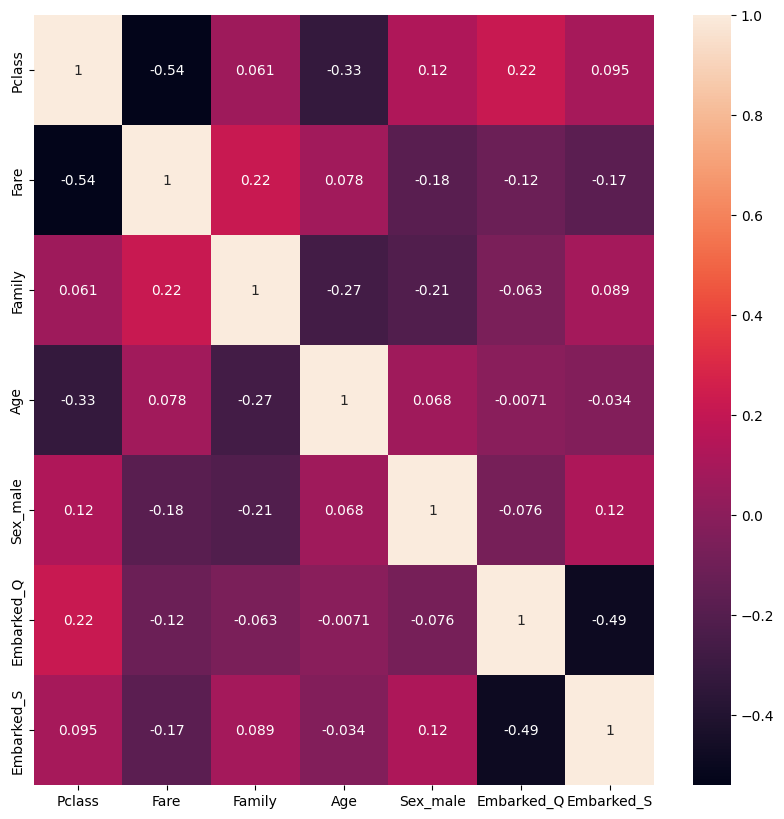

In [88]:
plt.figure(figsize=(10, 10))
sns.heatmap(X_train.corr(), annot=True)
#

## #Implement machine learning model and check accuracy

In [95]:
from sklearn.linear_model import LogisticRegression

In [97]:
#Implement logistic regression

model = LogisticRegression()
model.fit(X_train, Y_train)

model.score(X_test, Y_test)

0.8044692737430168

In [98]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, Y_train)

model.score(X_test, Y_test)

0.7821229050279329

In [101]:
import xgboost as xgb

model = xgb.XGBClassifier()
model.fit(X_train, Y_train)

model.score(X_test, Y_test)

0.8044692737430168

In [100]:
import sklearn.ensemble as ensemble

model = ensemble.RandomForestClassifier()
model.fit(X_train, Y_train)

model.score(X_test, Y_test)

0.8100558659217877

Random forest gives best accuracy.

In [102]:
model.predict(X_test)

array([1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1])